# 7.3 激活函数导数

## 7.3.1 Sigmoid 函数导数

为了帮助理解反向传播算法的实现细节，本章选择不使用 TensorFlow 的自动求导功
能，本章的实现部分全部使用 Numpy 演示，将使用 Numpy 实现一个通过反向传播算法优
化的多层神经网络。这里通过 Numpy 实现 Sigmoid 函数的导数，代码如下

In [19]:
import numpy as np


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def derivative(x): 
    return sigmoid(x) * (1 - sigmoid(x))

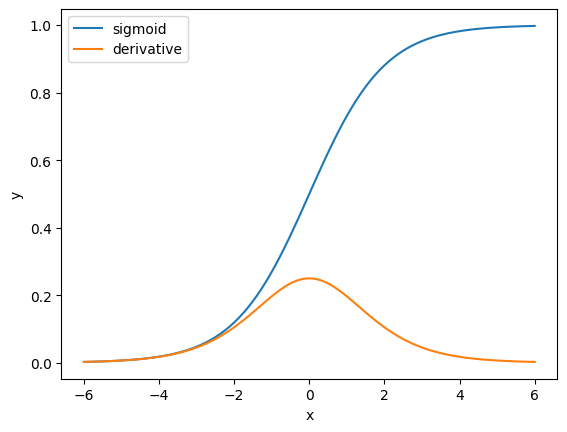

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 100)
y = [sigmoid(y).tolist() for y in x]
plt.plot(x, y, label='sigmoid')
y = [derivative(y).tolist() for y in x]
plt.plot(x, y, label='derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 7.3.2 ReLU 函数导数  
在 ReLU 函数被广泛应用之前，神经网络中激活函数采用 Sigmoid 居多，但是 Sigmoid
函数容易出现梯度弥散现象，当网络的层数增加后，较前层的参数由于梯度值非常微小，
参数长时间得不到有效更新，无法训练较深层的神经网络，导致神经网络的研究一直停留
在浅层。随着 ReLU 函数的提出，很好地缓解了梯度弥散的现象，神经网络的层数能够地
达到较深层数，如 AlexNet 中采用了 ReLU 激活函数，层数达到了 8 层，后续提出的上百
层的卷积神经网络也多是采用 ReLU 激活函数。
通过 Numpy，我们可以方便地实现 ReLU 函数的导数，代码如下：

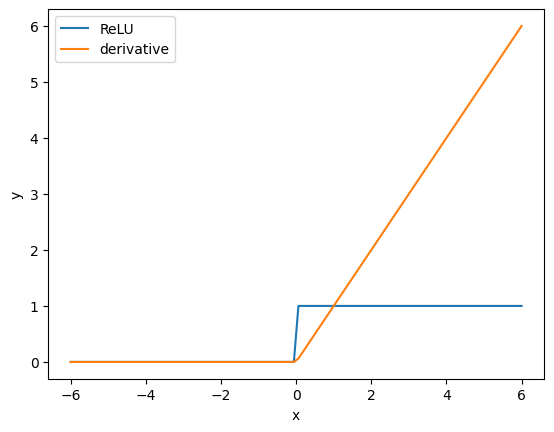

In [39]:
def derivative(x):
    d = np.array(x, copy=True)
    d[x < 0] = 0
    d[x >= 0] = 1
    return d


x = np.linspace(-6, 6, 100)
y = derivative(x)

plt.plot(x, y, label='ReLU')
plt.plot(x, [i if i > 0 else 0 for i in x], label='derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 7.3.3 LeakyReLU 函数导数  
它和 ReLU 函数的不同之处在于，当 x 小于零时，LeakyReLU 函数的导数值并不为 0，而
是常数𝑝，p 一般设置为某较小的数值，如 0.01 或 0.02，LeakyReLU 函数有效的克服了 ReLU 函数的缺陷，使用也比较广泛。我们可以通过
Numpy 实现 LeakyReLU 函数的导数，代码如下：

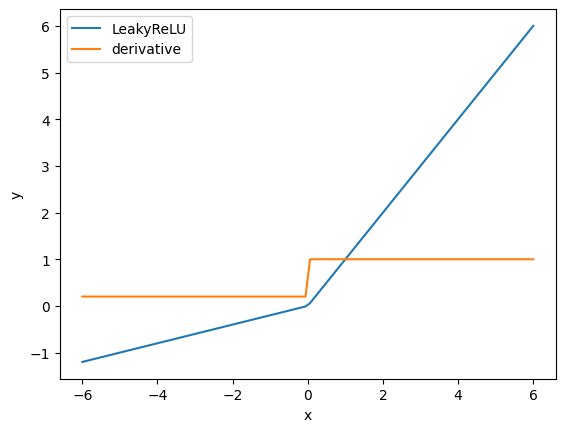

In [45]:
# 其中 p 为 LeakyReLU 的负半段斜率，为超参数
def derivative(x, p):
    dx = np.ones_like(x)
    dx[x < 0] = p
    return dx


x = np.linspace(-6, 6, 100)
y = [y if y > 0 else 0.2 * y for y in x]
plt.plot(x, y, label='LeakyReLU')
plt.plot(x, derivative(x, 0.2), label='derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 7.3.4 Tanh 函数梯度  
在 Numpy 中，借助于 Sigmoid 函数实现 Tanh 函数的导数，代码如下：

In [47]:
def sigmoid(x):  # sigmoid 函数实现
    return 1 / (1 + np.exp(-x))


def tanh(x):  # tanh 函数实现
    return 2*sigmoid(2 * x) - 1


def derivative(x):  # tanh 导数实现
    return 1 - tanh(x) ** 2

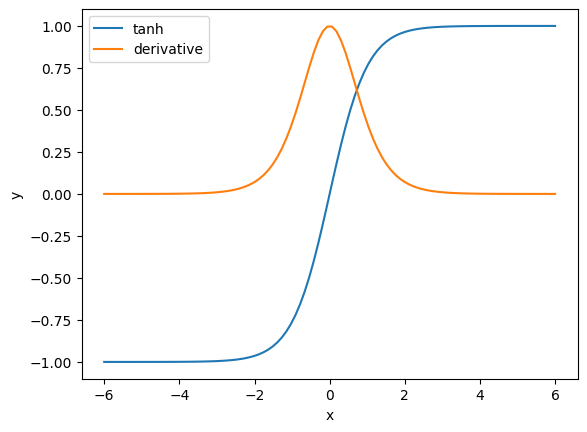

In [48]:
x = np.linspace(-6, 6, 100)
plt.plot(x, tanh(x), label='tanh')
plt.plot(x, derivative(x), label='derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()